# Final Project - Medical Insurance - Patient Health Risk Classification
## Phase 2 & 3: Data Preprocessing + Baseline Logistic Regression Model

**Course:** AIGC 5005 - AI Capstone Project Preparation\
**Dataset:** `medical_insurance.csv` (https://www.kaggle.com/datasets/mohankrishnathalla/medical-insurance-cost-prediction)\
**Task:** Binary Classification - Predict whether a patient is high health risk (`is_high_risk = 1`) or not (`is_high_risk = 0`)

---
### Dataset Overview
- **100,000 rows** - large enough for robust training/evaluation
- **54 original columns** → cleaned to **65 features** after removing leakage, redundant columns and encoding
- **Class balance:** ~63% negative / ~37% positive - `class_weight='balanced'` used in the model to address

---
### Notebook Structure
1. Imports & Configuration
2. Data Loading & Initial Exploration
3. Data Preprocessing
   - Drop leaky / non-predictive features
   - Encode categorical variables
   - Scale numerical features
   - Address class imbalance
4. Train / Validation / Test Split
5. Save Cleaned Data
6. Baseline Model - Logistic Regression
7. Evaluation & Metrics
8. Summary

---
## 1. Imports & Configuration
All required libraries are imported here. `pandas` and `numpy` handle data manipulation, `matplotlib` and `seaborn` handle visualisation, `sklearn` provides preprocessing and evaluation utilities

In [25]:
# Data manipulation ----------------------------------------------------------------
import numpy as np
import pandas as pd

# Visualisation --------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: preprocessing ------------------------------------------------------
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler

# Scikit-learn: model --------------------------------------------------------------
from sklearn.linear_model import LogisticRegression

# Scikit-learn: metrics ------------------------------------------------------------
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

# Standard library -----------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')

# Reproducibility ------------------------------------------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style -----------------------------------------------------------------------
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'axes.titlesize': 13, 'axes.labelsize': 11})

print("All libraries imported successfully.")

All libraries imported successfully.


---
## 2. Data Loading & Initial Exploration
### 2.1 Load Dataset
The raw CSV is loaded and the number of rows and columns are printed along with the first 5 rows to confirm the data loaded correctly.

In [26]:
# Load raw CSV
df = pd.read_csv('medical_insurance.csv')
print(f"Dataset shape: {df.shape}  ({df.shape[0]:,} rows × {df.shape[1]} columns)") # Print the number of rows and columns of dataset  
df.head()

Dataset shape: (100000, 54)  (100,000 rows × 54 columns)


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


### 2.2 Data Types and Null Counts

In [27]:
# Column data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

### 2.3 Describe Statistics for Numerical Columns

In [28]:
# Descriptive statistics for numerical columns
df.describe().T.style.background_gradient(cmap='Blues', axis=1)

,count,mean,std,min,25%,50%,75%,max
person_id,100000.000000,50000.500000,28867.657797,1.000000,25000.750000,50000.500000,75000.250000,100000.000000
age,100000.000000,47.521500,15.988752,0.000000,37.000000,48.000000,58.000000,100.000000
income,100000.000000,49873.905000,46800.214127,1100.000000,21100.000000,36200.000000,62200.000000,1061800.000000
household_size,100000.000000,2.430900,1.075126,1.000000,2.000000,2.000000,3.000000,9.000000
dependents,100000.000000,0.898380,0.950654,0.000000,0.000000,1.000000,1.000000,7.000000
bmi,100000.000000,26.990512,4.994883,12.000000,23.600000,27.000000,30.400000,50.400000
visits_last_year,100000.000000,1.927650,1.737730,0.000000,1.000000,2.000000,3.000000,25.000000
hospitalizations_last_3yrs,100000.000000,0.093640,0.304848,0.000000,0.000000,0.000000,0.000000,3.000000
days_hospitalized_last_3yrs,100000.000000,0.373350,1.373011,0.000000,0.000000,0.000000,0.000000,21.000000
medication_count,100000.000000,1.236320,1.209358,0.000000,0.000000,1.000000,2.000000,11.000000


### 2.4 Check for Missing and Duplicate Values

In [29]:
# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values found")

# Check for duplicate values
dup = df.duplicated().sum()
print(f"\nDuplicate Values: {dup}")

Missing values per column:
alcohol_freq    30083
dtype: int64

Duplicate Values: 0


### 2.5 Visualize Target Label Distribution

Label distribution:
              Count  Percentage (%)
is_high_risk                       
0             63219           63.22
1             36781           36.78


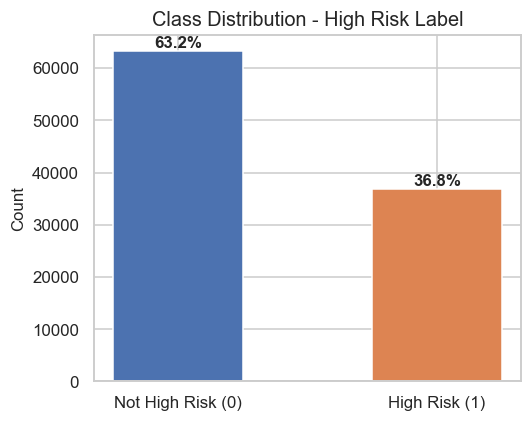

Imbalance ratio (majority:minority) ≈ 0.6:1  → class imbalance present
will use class_weight="balanced" in the model.


In [30]:
# Target label distribution
TARGET   = 'is_high_risk'
label_counts = df[TARGET].value_counts()
label_pct = df[TARGET].value_counts(normalize=True) * 100

print("Label distribution:")
print(pd.DataFrame({'Count': label_counts, 'Percentage (%)': label_pct.round(2)}))

# Plot: Class Distribution bar chart
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(
    ['Not High Risk (0)', 'High Risk (1)'],
    label_counts.values,
    color=['#4C72B0', '#DD8452'],
    edgecolor='white',
    width=0.5
)
# Add percentage labels above each bar
for bar, pct in zip(bars, label_pct.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 60,
            f"{pct:.1f}%",
            ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_title("Class Distribution - High Risk Label")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# Print imbalance ratio
imbalance_ratio = label_counts[0] / label_counts[1]
print(f"Imbalance ratio (majority:minority) ≈ {1/imbalance_ratio:.1f}:1  → class imbalance present")
print(f"will use class_weight=\"balanced\" in the model.")

### 2.6 Feature Correlation Matrix (Top 10 Numerical Features vs Target)
A correlation matrix is plotted across all numeric features and the top 10 features most strongly correlated with the target variable, `is_high_risk`, are selected for the visualisation. Using absolute correlation values ensures that both positive and negative relationships are considered. A strong negative correlation is just as predictive as a strong positive one. The heatmap makes it easy to spot which features are most informative for predicting risk, and the printed ranking identifies the single strongest predictor to reference during the presentation.

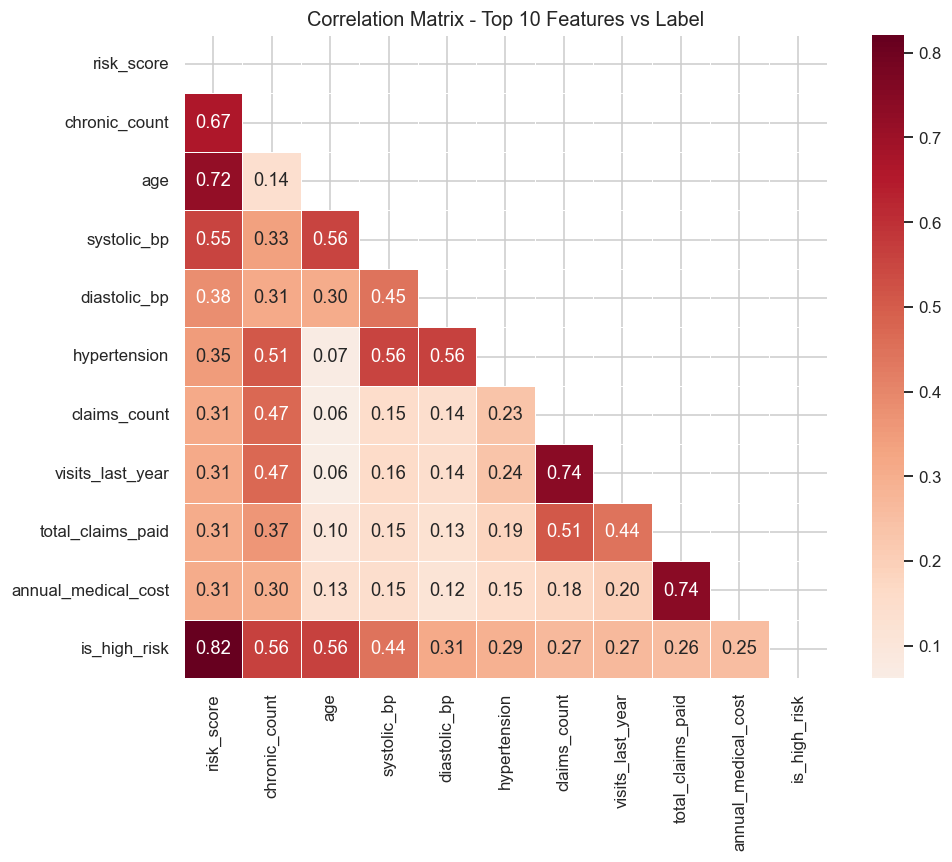

Top 10 correlations with Target Variable (sorted by absolute value):
risk_score             0.821276
chronic_count          0.561624
age                    0.559152
systolic_bp            0.442861
diastolic_bp           0.308214
hypertension           0.291361
claims_count           0.265279
visits_last_year       0.265066
total_claims_paid      0.256373
annual_medical_cost    0.251923
Name: is_high_risk, dtype: float64

Strongest predictor: risk_score (0.821)


In [31]:
# Select all numeric columns
num_cols = df.select_dtypes(include='number').columns.drop(TARGET).tolist() + [TARGET]
corr_matrix = df[num_cols].corr()

# Get top 10 features most correlated with target (by absolute value)
top10 = corr_matrix[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(10).index.tolist()
top10_cols = top10 + [TARGET]

# Compute correlation matrix for top features + target
corr = df[top10_cols].corr()
# Upper-triangle mask to avoid duplicate entries in heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))

# Plot: Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr, mask=mask,
    annot=True, fmt=".2f",
    cmap='RdBu_r', center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Correlation Matrix - Top 10 Features vs Label')
plt.tight_layout()
plt.show()

# Print ranked feature-target correlations
corr_with_label = corr[TARGET].drop(TARGET)
corr_with_label = corr_with_label.reindex(corr_with_label.abs().sort_values(ascending=False).index)
print("Top 10 correlations with Target Variable (sorted by absolute value):")
print(corr_with_label)
print(f"\nStrongest predictor: {corr_with_label.index[0]} ({corr_with_label.iloc[0]:.3f})")

---
## 3. Data Preprocessing

### 3.1 Drop Columns and Impute Nulls
- `person_id` is a unique row identifier assigned purely for tracking purposes. It carries no predictive signal and if it's included as a feature, the model might attempt to learn patterns from arbitrary ID values rather than the meaningful patient characteristics. 
- `risk_score` has a correlation of 0.82 with the target, so we drop it to prevent leaky features.
- `monthly_premium` is the same as annual_premium just divided by 12, so we drop it since it is redundant.
- `alcohol_freq` has missing values we need to impute with "None", since missing means they don't drink.

In [32]:
# Store a clean working copy; keep the original df untouched for reference
data = df.copy()

# Columns to drop before any modelling
data.drop(columns=['person_id', 'risk_score', 'monthly_premium'], inplace=True)

print(f"Dropped: {['person_id', 'risk_score', 'monthly_premium']}")
print(f"Remaining columns ({len(data.columns)}): {data.columns.tolist()}")

# Impute missing alcohol_freq - missing value means non-drinker
data['alcohol_freq'].fillna('Not Applicable', inplace=True)
print(f"\nImputed {['alcohol_freq']} with 'Not Applicable'")

Dropped: ['person_id', 'risk_score', 'monthly_premium']
Remaining columns (51): ['age', 'sex', 'region', 'urban_rural', 'income', 'education', 'marital_status', 'employment_status', 'household_size', 'dependents', 'bmi', 'smoker', 'alcohol_freq', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'plan_type', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'annual_medical_cost', 'annual_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure']

Imputed ['alcohol_freq'] with 'Not Applicable'


### 3.2 Encode Categorical Features
Since the model being used for this data will be Logistic Regression, all inputs are required to be encoded into numeric values. The target `is_high_risk` is already encoded as an ordered integer (Not High Risk=0, High Risk=1). Features with a clear natural hierarchy are encoded ordinally to preserve that ordering. All remaining nominal features are one-hot encoded using `pd.get_dummies` with `drop_first=True` to avoid multicollinearity.

The following is a breakdown of the features and how they should be encoded:

| Feature | Encoding | Rationale |
|---|---|---|
| `education` | Ordinal (No HS=0, HS=1, Some College=2, Bachelors=3, Masters=4, Doctorate=5) | Clear educational attainment hierarchy |
| `network_tier` | Ordinal (Bronze=0, Silver=1, Gold=2, Platinum=3) | Reflects insurance coverage quality hierarchy |
| `sex` | One-Hot (drop Female as baseline) | Nominal with 3 levels (Female, Male, Other) |
| `region` | One-Hot (drop Central as baseline) | Nominal, 5 regions with no natural ordering |
| `urban_rural` | One-Hot (drop Rural as baseline) | Nominal location type with no inherent order |
| `marital_status` | One-Hot (drop Divorced as baseline) | Nominal, 4 categories |
| `employment_status` | One-Hot (drop Employed as baseline) | Nominal, 4 categories |
| `smoker` | One-Hot (drop Current as baseline) | Nominal smoking status |
| `alcohol_freq` | One-Hot (drop Daily as baseline) | Nominal frequency, including imputed "Not Applicable" |
| `plan_type` | One-Hot (drop EPO as baseline) | Nominal insurance plan types (HMO, POS, PPO, EPO) |

In [33]:
# Quick look at unique values for each categorical feature
cat_cols = df.select_dtypes(exclude='number').columns.tolist()
print("Categorical columns and their unique values:")
for col in cat_cols:
    print(f"  {col:20s}: {sorted(data[col].unique().tolist())}")

Categorical columns and their unique values:
  sex                 : ['Female', 'Male', 'Other']
  region              : ['Central', 'East', 'North', 'South', 'West']
  urban_rural         : ['Rural', 'Suburban', 'Urban']
  education           : ['Bachelors', 'Doctorate', 'HS', 'Masters', 'No HS', 'Some College']
  marital_status      : ['Divorced', 'Married', 'Single', 'Widowed']
  employment_status   : ['Employed', 'Retired', 'Self-employed', 'Unemployed']
  smoker              : ['Current', 'Former', 'Never']
  alcohol_freq        : ['Daily', 'Not Applicable', 'Occasional', 'Weekly']
  plan_type           : ['EPO', 'HMO', 'POS', 'PPO']
  network_tier        : ['Bronze', 'Gold', 'Platinum', 'Silver']


In [34]:
# Nominal categorical features to one-hot encode
data = pd.get_dummies(data, columns=['sex', 'region', 'urban_rural', 'marital_status', 'employment_status', 'smoker', 'alcohol_freq', 'plan_type'], drop_first=True)

# education: ordinal
data['education'] = data['education'].map(
    {'No HS': 0, 'HS': 1, 'Some College': 2, 'Bachelors': 3, 'Masters': 4, 'Doctorate' : 5}
)

# network_tier: ordinal by tier
data['network_tier'] = data['network_tier'].map(
    {'Bronze': 0, 'Silver': 1, 'Gold': 2, 'Platinum': 3}
)

print(f"Shape after encoding: {data.shape}")
print(f"Columns: {data.columns.tolist()}")

Shape after encoding: (100000, 65)
Columns: ['age', 'income', 'education', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'annual_medical_cost', 'annual_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count', 'is_high_risk', 'had_major_procedure', 'sex_Male', 'sex_Other', 'region_East', 'region_North', 'region_South', 'region_West', 'urban_rural_Suburban', 'urban_rural_Urban', 'marital_status_Married', 'marital_status_Single', 'marital_status_Widowed', 'employ

### 3.3 Check for Skewness and Cap Outliers on Numerical Features
Extreme outliers in numeric features can distort model training by pulling the learned decision boundaries toward unusual edge cases that rarely occur. All numeric columns are capped at the 1st and 99th percentiles, which removes the most extreme 2% of values while preserving the overall shape of each distribution.

In [35]:
# Identify numeric columns to cap outliers
num_cols = data.select_dtypes(include='number').columns.tolist()

# Split into binary vs continuous
binary_cols = [col for col in num_cols if data[col].nunique() <= 2]
continuous_cols = [col for col in num_cols if data[col].nunique() > 2]

print(f"Binary columns ({len(binary_cols)}): {binary_cols}")
print(f"Continuous columns ({len(continuous_cols)}): {continuous_cols}\n")

Binary columns (12): ['hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 'mental_health', 'is_high_risk', 'had_major_procedure']
Continuous columns (31): ['age', 'income', 'education', 'household_size', 'dependents', 'bmi', 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'network_tier', 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality', 'annual_medical_cost', 'annual_premium', 'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count', 'proc_lab_count']



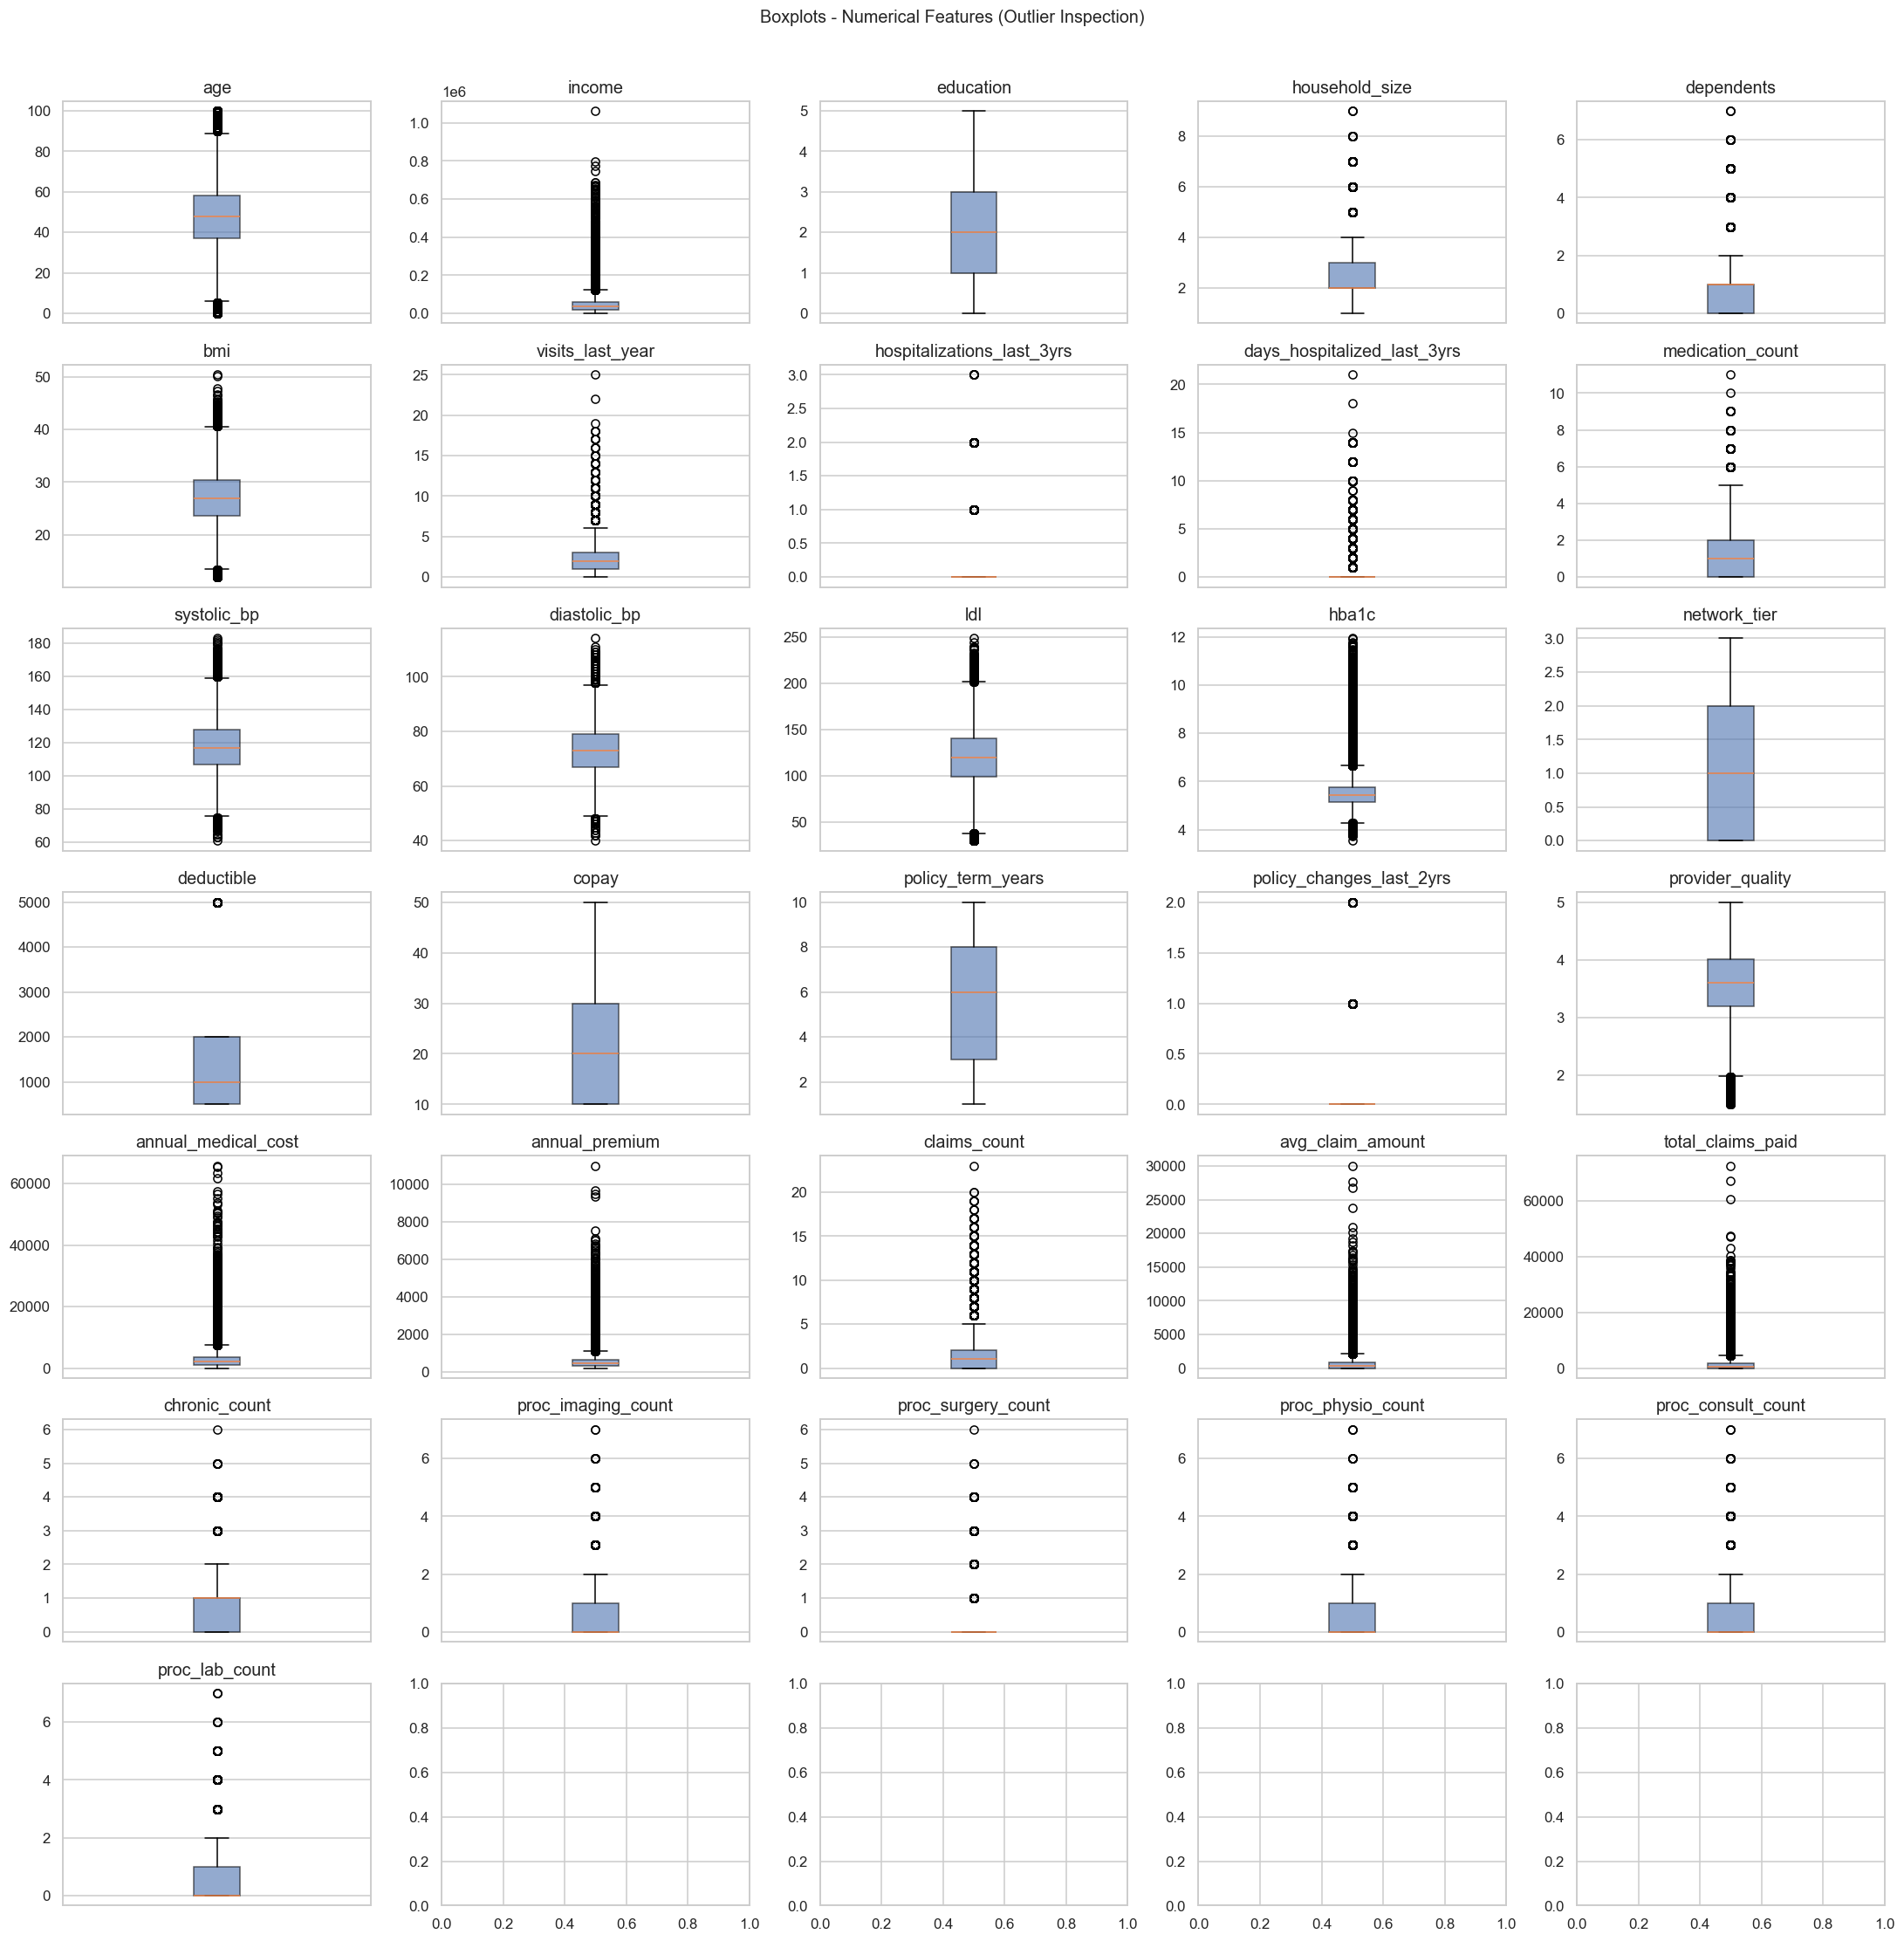

In [36]:
# Plot boxplots for continuous features to inspect outliers
fig, axes = plt.subplots(7, 5, figsize=(20, 20))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    axes[i].boxplot(data[col], vert=True, patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6))
    axes[i].set_title(col)
    axes[i].set_xticks([])

plt.suptitle("Boxplots - Numerical Features (Outlier Inspection)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Before scaling and modeling, the continuous numerical features need to be checked for two common problems that can hurt model performance. The first is skewness as many real-world financial and medical features like `total_claims_paid`, `income`, and `hospitalizations_last_3yrs` have a small number of patients with extreme values that pull the distribution into a long right tail. When a feature is heavily skewed, the model sees most of its training examples clustered in a narrow range and only a handful of examples in the stretched-out tail, making it hard to learn a reliable pattern across the full range of values. Applying a log1p transform to any column with skewness above 1, compresses that tail and brings the distribution closer to a normal shape, which helps Logistic Regression converge faster and more stably. The second problem is outliers, since even after the log transform, some features may still have a small number of extreme values at the very edges of their distribution. These are capped at the 1st and 99th percentiles, meaning any value below the bottom 1% is pulled up to that floor and any value above the top 99% is pulled down to that ceiling. This prevents a handful of unusual patients from having an outsized influence on the model's learned weights, while still keeping every row in the dataset rather than deleting any records.

In [37]:
# Check skewness
skewness = data[continuous_cols].skew().sort_values(ascending=False)
print("\nSkewness of continuous features:")
print(skewness)

# Apply log transform to highly skewed features
# Rule: skew > 1 → apply log1p
# Flag features with skewness > 1 for log transform
skewed_cols = skewness[skewness > 1].index.tolist()
print(f"\nApplying log1p transform to: {skewed_cols}")
# Apply log1p to compress right-skewed distributions
for col in skewed_cols:
    data[col] = np.log1p(data[col])


# Cap extreme values 
# Clip each continuous feature at 1st and 99th percentile
cap_summary = []

for col in continuous_cols:
    # Compute clipping bounds
    lower = data[col].quantile(0.01)
    upper = data[col].quantile(0.99)
    
    # % and num of values outside bounds before capping
    outlier_pct = ((data[col] < lower) | (data[col] > upper)).mean()
    outlier_num = ((data[col] < lower) | (data[col] > upper)).sum()
    
    # Only clip if more than 1% of values are outside bounds
    if outlier_pct > 0.01:
        data[col] = data[col].clip(lower, upper)
        cap_summary.append((col, round(outlier_pct * 100, 2), outlier_num))

print("\nColumns capped (with % of outliers before capping):")
for col, pct, num in cap_summary:
    print(f"{col}: {pct}% ({num} values)")


Skewness of continuous features:
total_claims_paid              4.938078
avg_claim_amount               4.642195
policy_changes_last_2yrs       4.400438
annual_premium                 4.364620
days_hospitalized_last_3yrs    4.257994
annual_medical_cost            4.030318
proc_surgery_count             3.472609
income                         3.390437
hospitalizations_last_3yrs     3.225356
hba1c                          2.637342
deductible                     2.497308
claims_count                   2.086701
proc_consult_count             1.655806
proc_lab_count                 1.629823
proc_imaging_count             1.627069
proc_physio_count              1.606152
visits_last_year               1.598202
copay                          1.224766
medication_count               1.143470
dependents                     1.062228
chronic_count                  0.977679
household_size                 0.725711
network_tier                   0.517578
systolic_bp                    0.262804
diasto

### 3.4 Post Clean-Up Summary
A final inspection is run after all cleaning steps to confirm the dataset is in a valid state before proceeding. This checks that no null values or duplicate rows remain, that the encoded target and ordinal columns contain only their expected values, and that the column type breakdown reflects the fully numeric dataset expected by Logistic Regression.

In [38]:
# Print Cleaning Summary
print(f"Post-Cleaning Validation:")
print(f"Shape         : {data.shape}")
print(f"Remaining NaNs: {data.isnull().sum().sum()}")
print(f"Duplicates    : {data.duplicated().sum()}")

print("\nDtype counts:")
print(data.dtypes.value_counts())

print(f"\nData columns (Features: {data.shape[1]}):")
print(data.columns)

print("\nSample (first 3 rows, numeric only):")
data.select_dtypes(include='number').head(3)

Post-Cleaning Validation:
Shape         : (100000, 65)
Remaining NaNs: 0
Duplicates    : 0

Dtype counts:
float64    25
bool       22
int64      18
Name: count, dtype: int64

Data columns (Features: 65):
Index(['age', 'income', 'education', 'household_size', 'dependents', 'bmi',
       'visits_last_year', 'hospitalizations_last_3yrs',
       'days_hospitalized_last_3yrs', 'medication_count', 'systolic_bp',
       'diastolic_bp', 'ldl', 'hba1c', 'network_tier', 'deductible', 'copay',
       'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality',
       'annual_medical_cost', 'annual_premium', 'claims_count',
       'avg_claim_amount', 'total_claims_paid', 'chronic_count',
       'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease',
       'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis',
       'mental_health', 'proc_imaging_count', 'proc_surgery_count',
       'proc_physio_count', 'proc_consult_count', 'proc_lab_count',
       'is_high_ris

,age,income,education,household_size,dependents,bmi,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,52,10.030164,5,3,0.693147,27.4,1.098612,0.0,0.0,1.609438,...,0,1,0,0.693147,0.0,1.098612,0.000000,0.693147,0,0
1,79,9.457279,0,3,0.693147,26.6,1.098612,0.0,0.0,1.386294,...,0,1,1,0.000000,0.0,0.693147,0.000000,0.693147,1,0
2,68,10.614008,1,5,1.386294,31.5,0.693147,0.0,0.0,1.609438,...,0,0,1,0.693147,0.0,1.098612,0.693147,0.000000,1,0


---
## 4. Train / Validation / Test Split

### 4.1 Split Data
The cleaned dataset is split into three sets using a 70/15/15 ratio. Stratified sampling is applied so that the label classes are proportionally represented in all three splits, preventing any split from being skewed toward one class by chance. The train set is used to fit the model weights, the validation set is used to monitor performance during training, and the test set is held out entirely and only used during the final inferencing step to give an unbiased measure of real-world performance. 

In [39]:
# Separate features and target
X = data.drop(columns=[TARGET])
y = data[TARGET]

print(f"Feature matrix X: {X.shape}")
print(f"Target vector  y: {y.shape}")

# Save feature names for use in Section 7 (feature importance)
feature_names = X.columns

# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=RANDOM_STATE, stratify=y
)

# Second split: split the 30% temp equally into val (15%) and test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

print(f"\nTrain size : {X_train.shape[0]:,}  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Val size : {X_val.shape[0]:,}  ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test size : {X_test.shape[0]:,}  ({X_test.shape[0]/len(X)*100:.0f}%)")

# Confirm class ratios are preserved
for name, ys in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    pos_pct = ys.mean() * 100
    print(f"  {name} - positive class rate: {pos_pct:.1f}%")

Feature matrix X: (100000, 64)
Target vector  y: (100000,)

Train size : 70,000  (70%)
Val size : 15,000  (15%)
Test size : 15,000  (15%)
  Train - positive class rate: 36.8%
  Val - positive class rate: 36.8%
  Test - positive class rate: 36.8%


### 4.2 Scale Numerical Features
Numerical features were standardized using StandardScaler, fit on the training set only and then applied to the validation and test sets. This was necessary because the dataset contains features on very different scales. For example, binary indicator features range from 0 to 1, while features like `annual_medical_cost` or `income` span much larger ranges. Standardization rescales each feature so that no single feature dominates the model due to its magnitude rather than its predictive value, allowing the optimization algorithm to converge reliably.

In [40]:
# StandardScaler is fit ONLY on train set to prevent data leakage
# The same fitted scaler is then applied to val and test.
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit + transform
X_val   = scaler.transform(X_val)         # transform only
X_test  = scaler.transform(X_test)        # transform only

print("StandardScaler applied - numerical features normalised (μ=0, σ=1).")
print(f"Feature means after scaling (train): {X_train.mean().round(4)}")

StandardScaler applied - numerical features normalised (μ=0, σ=1).
Feature means after scaling (train): 0.0


---
## 5. Save Cleaned Data
Save the cleaned data so it can be used for the advanced model without repeating the same steps.

In [41]:
import joblib, os

SAVE_DIR = 'prepared_data'
os.makedirs(SAVE_DIR, exist_ok=True)

# Save the train/val/test splits 
joblib.dump({'X_train': X_train, 'X_val': X_val, 'X_test': X_test,
             'y_train': y_train, 'y_val': y_val, 'y_test': y_test},
            f'{SAVE_DIR}/splits.pkl')

# Save the fitted scaler (prevents leakage in the advanced notebook)
joblib.dump(scaler, f'{SAVE_DIR}/scaler.pkl')

# Save the full cleaned DataFrame
data.to_csv(f'{SAVE_DIR}/cleaned_data.csv', index=False)

print(f"Saved to '{SAVE_DIR}/':")
print("  splits.pkl  - X/y train/val/test")
print("  scaler.pkl  - fitted StandardScaler")
print("  cleaned_data.csv - full cleaned/encoded DataFrame")

Saved to 'prepared_data/':
  splits.pkl  - X/y train/val/test
  scaler.pkl  - fitted StandardScaler
  cleaned_data.csv - full cleaned/encoded DataFrame


---
## 6. Baseline Model - Logistic Regression

Logistic Regression was selected as the baseline classification algorithm due to its interpretability and suitability for binary classification tasks. It models the log-odds of the positive class as a linear combination of input features and outputs a probability between 0 and 1, which is then converted into a class label using a decision threshold.

Since the dataset is imbalanced, with approximately 37% of patients labelled as high risk, this was addressed by setting class_weight='balanced', which automatically weights each class inversely proportional to its frequency in the training data. This penalizes the model more heavily for missing a high-risk patient, since in a clinical context a false negative, failing to identify a high-risk patient, carries a greater cost than a false alarm.

The lbfgs solver was selected as it handles L2 regularization efficiently and scales well to medium to large datasets. The regularization strength was kept at the default C=1.0, providing a balanced trade-off between bias and variance for the 70,000 training samples available. max_iter=1000 was set to ensure the optimizer fully converges.

In [42]:
# Initialize and train the baseline model 
baseline = LogisticRegression(
    C=1.0,                    # inverse regularisation strength (default)
    solver='lbfgs',           # efficient for small-medium datasets
    max_iter=1000,            # ensure convergence
    class_weight='balanced',  # adjust for 77:23 imbalance
    random_state=RANDOM_STATE
)

# Train on the training set
baseline.fit(X_train, y_train)
print("Logistic Regression baseline trained")

Logistic Regression baseline trained


### 6.1 Cross-Validation

Rather than relying on a single train/validation split to assess generalization, 5-fold Stratified Cross-Validation is applied to the training set. This technique divides the training data into five equally sized folds and iteratively trains the model on four folds while evaluating it on the remaining one, cycling through all five combinations. The stratified variant is used specifically because the dataset is class-imbalanced and stratification ensures that every fold maintains the same approximately 63:37 class ratio as the full training set, so no fold contains an unrepresentative proportion of high-risk patients. The F1-score and ROC-AUC are reported for each fold individually as well as their mean and standard deviation. A low standard deviation across folds indicates that the model's performance is stable and not sensitive to which particular subset of data it is trained on. This is a key indicator that the learned patterns generalize beyond the training sample rather than reflecting noise in one particular partition.

In [43]:
# 5-fold Stratified Cross-Validation on the training set 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_f1  = cross_val_score(baseline, X_train, y_train, cv=cv, scoring='f1')
cv_auc = cross_val_score(baseline, X_train, y_train, cv=cv, scoring='roc_auc')

print("5-Fold Stratified Cross-Validation Results (Train set):")
print(f"  F1   per fold: {[f'{v:.4f}' for v in cv_f1]}")
print(f"  F1   mean ± std: {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
print(f"  AUC  per fold: {[f'{v:.4f}' for v in cv_auc]}")
print(f"  AUC  mean ± std: {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

5-Fold Stratified Cross-Validation Results (Train set):
  F1   per fold: ['0.9581', '0.9555', '0.9586', '0.9543', '0.9595']
  F1   mean ± std: 0.9572 ± 0.0020
  AUC  per fold: ['0.9973', '0.9972', '0.9975', '0.9971', '0.9974']
  AUC  mean ± std: 0.9973 ± 0.0002


---
## 7. Evaluation & Metrics

Evaluation is conducted in three stages. The first being on the training set which tells how well the model has learned the patterns and relationships within the data it was trained on. However, this isn't a reliable indicator of how the model will perform on new, unseen data which is where the validation set comes into play The validation set is assessed first to give an indication of how the model performs on data it has not been trained on, while still leaving the option to make minor adjustments if the results are unexpected. The held-out test set is then evaluated exactly once to produce the final unbiased performance estimate. Using the test set more than once would risk overfitting to its specific distribution through repeated decision-making, which is why it is strictly kept separate until this final step. 

Accuracy alone is not a reliable metric in the presence of class imbalance. A naive classifier that always predicts 'not high risk' would achieve roughly 63% accuracy on this dataset while identifying zero high-risk patients. For this reason, four metrics are reported together. `Precision` (of all patients flagged as high risk, how many truly were), `Recall` (of all patients who genuinely were high risk, how many the model correctly identified), `F1-Score` (the harmonic mean of Precision and Recall, balancing both), and `ROC-AUC` (the probability that the model ranks a randomly chosen high-risk patient higher than a randomly chosen non-high-risk one). These metrics together give a complete and honest picture of model behavior across both classes.

### 7.1 Evaluation Helper

The function below computes predictions and all key metrics for a given split. It takes in the model, X values for train, validation and test to output their respective predications, probabilities and metrics.

In [44]:
def evaluate_model(model, X, y_true, set_name='Set'):
    # Generate predictions and probability scores
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]   # probability of positive class

    # Compute all metrics
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    auc  = roc_auc_score(y_true, y_prob)

    print(f"\n{'='*50}")
    print(f"  {set_name} - Classification Report")
    print(f"{'='*50}")
    print(classification_report(
        y_true, y_pred, 
        target_names=['Not High Risk', 'High Risk'], 
        zero_division=0
    ))

    return y_pred, y_prob, {
        'Accuracy' : acc, 'Precision': prec,
        'Recall'   : rec, 'F1-Score'  : f1, 'ROC-AUC': auc
    }


# Evaluate on all three splits
# Training set evaluation 
train_pred, train_prob, train_metrics = evaluate_model(baseline, X_train, y_train, 'Training')

# Validation set evaluation 
val_pred, val_prob, val_metrics = evaluate_model(baseline, X_val, y_val, 'Validation')

# Test set evaluation
test_pred, test_prob, test_metrics = evaluate_model(baseline, X_test, y_test, 'Test')



  Training - Classification Report
               precision    recall  f1-score   support

Not High Risk       0.98      0.97      0.97     44253
    High Risk       0.94      0.97      0.96     25747

     accuracy                           0.97     70000
    macro avg       0.96      0.97      0.97     70000
 weighted avg       0.97      0.97      0.97     70000


  Validation - Classification Report
               precision    recall  f1-score   support

Not High Risk       0.99      0.97      0.98      9483
    High Risk       0.95      0.97      0.96      5517

     accuracy                           0.97     15000
    macro avg       0.97      0.97      0.97     15000
 weighted avg       0.97      0.97      0.97     15000


  Test - Classification Report
               precision    recall  f1-score   support

Not High Risk       0.98      0.97      0.97      9483
    High Risk       0.94      0.97      0.96      5517

     accuracy                           0.97     15000
    ma

### 7.2 Confusion Matrix

The confusion matrix provides a breakdown of the model's predictions into four categories. `True Positives (TP)` are patients correctly identified as high health risk. `True Negatives (TN)` are patients correctly identified as not high risk. `False Positives (FP)` occur when the model flags a patient as high risk who is not actually high risk, generating unnecessary follow-up but causes no direct patient harm. `False Negatives (FN)`, however, carry the highest cost as these are patients who are genuinely high health risk but are missed by the model and therefore receive no additional care or intervention. In a health risk screening context, minimizing false negatives is typically the priority, which is reflected in the emphasis on Recall as a key metric. The confusion matrix makes these trade-offs explicit in a way that summary statistics cannot, and serves as an essential communication tool when presenting model behaviour to clinicians and stakeholders who may not be familiar with statistical metrics.

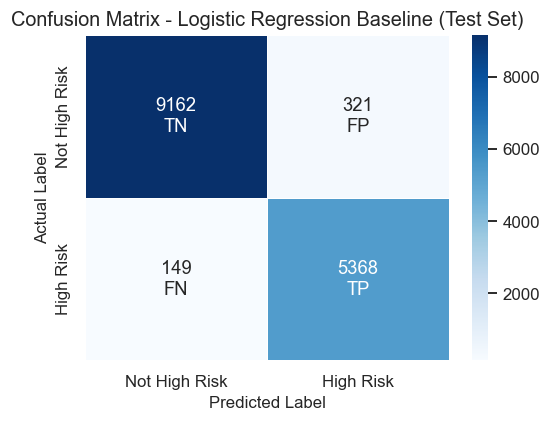

True Negatives  (TN): 9162 - Correctly predicted Not High Risk
False Positives (FP): 321  - Predicted High Risk, actually Not
False Negatives (FN): 149  - Predicted Not High Risk, actually High Risk (costly!)
True Positives  (TP): 5368 - Correctly predicted High Risk


In [45]:
# Confusion matrix - Test set
cm = confusion_matrix(y_test, test_pred)
# Unpack into individual counts
tn, fp, fn, tp = cm.ravel()

# Build annotation labels combining count + cell type (TN/FP/FN/TP)
labels = [[f"{tn}\nTN", f"{fp}\nFP"],
          [f"{fn}\nFN", f"{tp}\nTP"]]

# Plot: Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=labels, fmt="",
    cmap="Blues",
    xticklabels=["Not High Risk", "High Risk"],
    yticklabels=["Not High Risk", "High Risk"],
    linewidths=0.5,
    annot_kws={"size": 12},
    ax=ax
)
ax.set_xlabel("Predicted Label")
ax.set_ylabel("Actual Label")
ax.set_title("Confusion Matrix - Logistic Regression Baseline (Test Set)")
plt.tight_layout()
plt.show()

print(f"True Negatives  (TN): {tn} - Correctly predicted Not High Risk")
print(f"False Positives (FP): {fp}  - Predicted High Risk, actually Not")
print(f"False Negatives (FN): {fn}  - Predicted Not High Risk, actually High Risk (costly!)")
print(f"True Positives  (TP): {tp} - Correctly predicted High Risk")

### 7.3 ROC Curve and Precision-Recall Curve
The ROC curve plots the True Positive Rate (Recall) against the False Positive Rate across every possible classification threshold, showing how well the model separates high-risk from non-high-risk patients. The Area Under the Curve (AUC-ROC) summarises this into a single score. A value of 1.0 represents a perfect classifier while 0.5 represents a model equivalent to random guessing. A strong AUC-ROC score indicates the model consistently ranks genuinely high-risk patients above low-risk ones regardless of where the decision threshold is set.

The Precision-Recall curve is plotted alongside the ROC because it is more informative for imbalanced datasets. Rather than considering both classes equally, it focuses specifically on the model's performance on the positive (high-risk) class. Precision measures how many of the patients flagged as high risk truly were, while Recall measures how many of the genuinely high-risk patients the model successfully caught. In a health risk screening context this trade-off is critical, since a lower threshold catches more high-risk patients (higher Recall) but also generates more false alarms (lower Precision), while a higher threshold reduces false alarms but risks missing patients who need care or intervention.

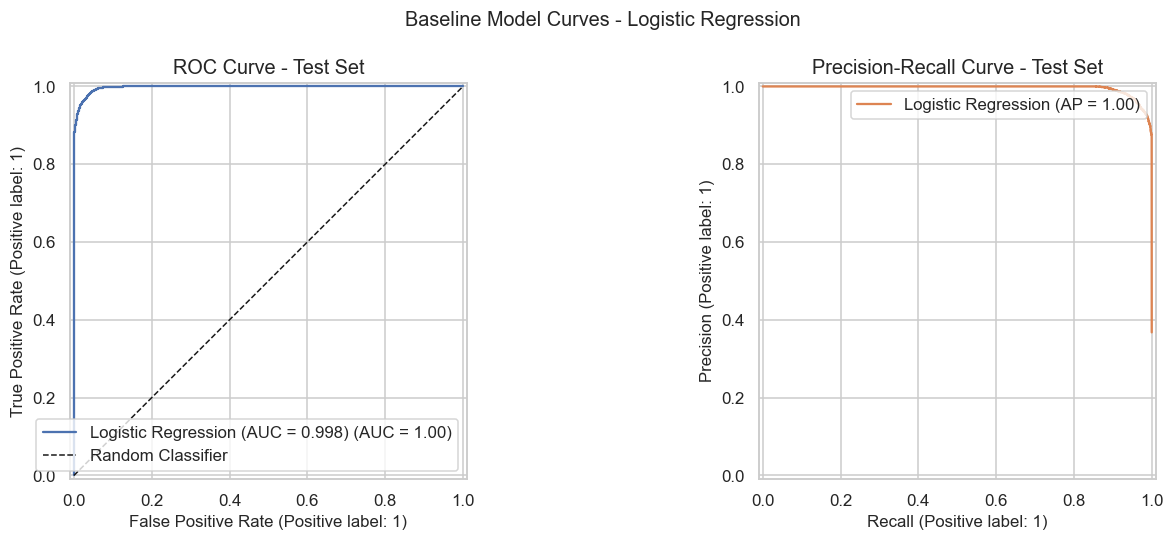

In [46]:
# Plot: ROC curve (left) and Precision-Recall curve (right)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

RocCurveDisplay.from_predictions(
    y_test, test_prob,
    name=f'Logistic Regression (AUC = {test_metrics["ROC-AUC"]:.3f})',
    ax=axes[0], color='#4C72B0'
)
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[0].set_title('ROC Curve - Test Set')
axes[0].legend(loc='lower right')

# Precision-Recall curve (better for imbalanced datasets)
PrecisionRecallDisplay.from_predictions(
    y_test, test_prob,
    name='Logistic Regression',
    ax=axes[1], color='#DD8452'
)
axes[1].set_title('Precision-Recall Curve - Test Set')
axes[1].legend(loc='upper right')

plt.suptitle('Baseline Model Curves - Logistic Regression', fontsize=13)
plt.tight_layout()
plt.show()

### 7.4 Feature Importance - Logistic Regression Coefficients

In a logistic regression model, each feature is assigned a single coefficient that quantifies its linear contribution to the log-odds of the positive class (high health risk). A positive coefficient means that higher values of that feature push the predicted probability toward high risk, while a negative coefficient pushes it toward not high risk. The top 15 features ranked by absolute coefficient magnitude are visualized here to identify which variables the model is relying on most heavily.

This analysis serves two purposes. First, it acts as a check to see if features like `region` or `plan_type` have more influence than health-related variables like `chronic_count` or `hospitalizations_last_3yrs`, it would suggest the model has picked up on a false patterns in the training data rather than a real health signal. Second, looking at the coefficients makes the model more transparent, which is important in a health risk screening context where decisions need to be explainable to clinicians and stakeholders. Features found to be highly influential can also point to areas where collecting better or more granular health data would improve the model in future iterations.

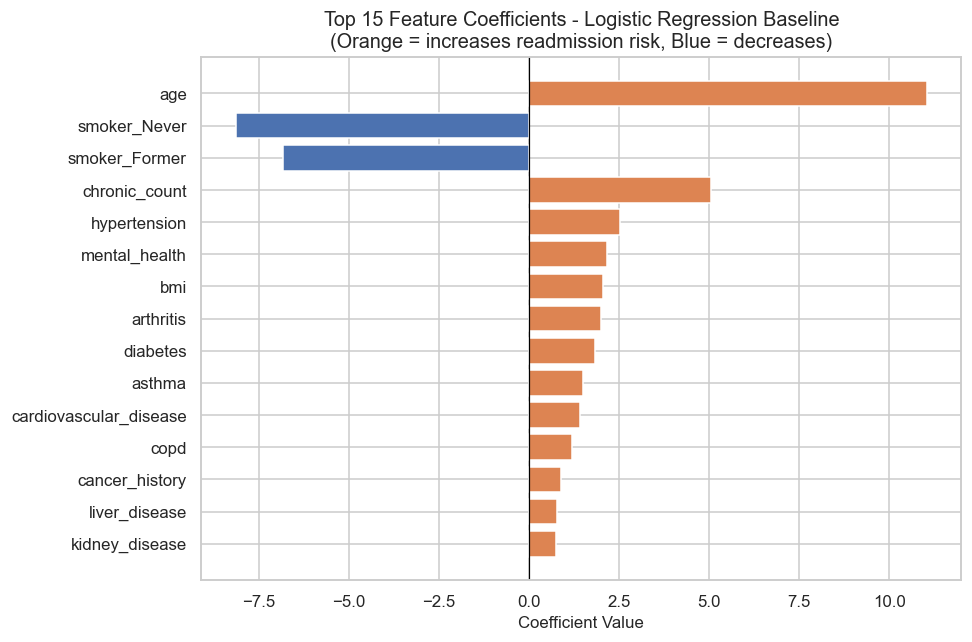

In [47]:
# Extract top 15 coefficients by absolute magnitude
coef_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Coefficient': baseline.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(15)

# Plot: Horizontal bar chart of feature coefficients
fig, ax = plt.subplots(figsize=(9, 6))
# Orange = positive coefficient (increases risk), blue = negative
colors = ['#DD8452' if c > 0 else '#4C72B0' for c in coef_df['Coefficient']]
ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_xlabel('Coefficient Value')
ax.set_title('Top 15 Feature Coefficients - Logistic Regression Baseline\n'
             '(Orange = increases readmission risk, Blue = decreases)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 7.5 Performance Summary Table

A performance summary table is created to compare training, validation, and test performance side by side across all five evaluation metrics. Close alignment between the three splits confirms that the model is generalizing well to unseen data rather than memorizing the training set. This generalization check is a critical step before declaring the baseline model fit for comparison. If significant overfitting were detected, it would indicate a need for stronger regularization (lower `C`), feature selection, or additional data before proceeding to more complex models.

This table also establishes the formal performance benchmark that the advanced model must exceed in order to justify its additional complexity. An advanced model that matches the baseline on all metrics provides no practical benefit and its extra computational cost and reduced interpretability cannot be justified. Only models that demonstrate a meaningful improvement on the minority-class metrics, particularly Recall and F1-Score for the high-risk class, will be considered successful.

In [48]:
# Train vs. Validation vs. Test metric summary table
summary = pd.DataFrame({
    'Split'    : ['Train', 'Validation', 'Test'],
    'Accuracy' : [
        train_metrics['Accuracy'],
        val_metrics['Accuracy'],
        test_metrics['Accuracy']
    ],
    'Precision': [
        train_metrics['Precision'],
        val_metrics['Precision'],
        test_metrics['Precision']
    ],
    'Recall'   : [
        train_metrics['Recall'],
        val_metrics['Recall'],
        test_metrics['Recall']
    ],
    'F1-Score' : [
        train_metrics['F1-Score'],
        val_metrics['F1-Score'],
        test_metrics['F1-Score']
    ],
    'ROC-AUC'  : [
        train_metrics['ROC-AUC'],
        val_metrics['ROC-AUC'],
        test_metrics['ROC-AUC']
    ],
}).set_index('Split')

print(f"\nBaseline Model - Performance Summary:")
summary.round(4).style.background_gradient(cmap='Greens', axis=0)


Baseline Model - Performance Summary:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Split,,,,,
Train,0.968400,0.944900,0.970600,0.957600,0.997400
Validation,0.970600,0.946700,0.975000,0.960600,0.997600
Test,0.968700,0.943600,0.973000,0.958100,0.997600


---
## 8. Summary

### Preprocessing Steps Completed
The table below lists every preprocessing decision made before model training, in the order they were applied.

| Step | Feature(s) | Action | Rationale |
|---|---|---|---|
| 1 | `person_id` | Dropped | Non-predictive row identifier |
| 2 | `risk_score` | Dropped | Correlation of 0.82 with target - data leakage |
| 3 | `monthly_premium` | Dropped | Redundant - equals `annual_premium / 12` |
| 4 | `alcohol_freq` | Imputed nulls with "Not Applicable" | 30,083 missing values; absence means non-drinker |
| 5 | `education` | Ordinal encoded (No HS=0 → Doctorate=5) | Clear educational attainment hierarchy |
| 6 | `network_tier` | Ordinal encoded (Bronze=0 → Platinum=3) | Reflects insurance coverage quality hierarchy |
| 7 | `sex`, `region`, `urban_rural`, `marital_status`, `employment_status`, `smoker`, `alcohol_freq`, `plan_type` | One-Hot encoded (drop_first=True) | Nominal features; drop_first avoids multicollinearity |
| 8 | 20 highly skewed continuous features | log1p transform (skewness > 1) | Reduces right-skew to improve logistic regression convergence |
| 9 | Continuous numerical features | Clipped at 1st and 99th percentile | Removes extreme outliers without dropping rows |
| 10 | All features | Train / Validation / Test split - 70 / 15 / 15 (stratified) | Preserves 63:37 class ratio in every split |
| 11 | All numerical features | StandardScaler fit on train only, applied to val and test | Prevents data leakage; normalises features to μ=0, σ=1 |
| 12 | Class imbalance (63:37) | `class_weight='balanced'` in LogisticRegression | Prevents the model from ignoring the minority (High Risk) class |

### Baseline Logistic Regression Performance Summary
The baseline Logistic Regression model performs consistently across all three splits, with training, validation, and test scores remaining closely aligned. This confirms that the model is generalizing well and not overfitting. The test set achieved an accuracy of approximately 96.87%, an F1-score of 0.9581 for the High Risk class, and a cross-validated ROC-AUC of 0.9976.

For the High Risk class, both Precision and Recall are strong, indicating the model reliably identifies high-risk patients while keeping false alarms low. The 5-fold cross-validation F1 mean of 0.9572 with a standard deviation of 0.002 further confirms that performance is stable across different subsets of the training data.

The primary objective for the advanced models will be to maintain this strong performance while exploring whether more complex algorithms can capture any non-linear patterns the logistic regression may have missed. Improving F1-Score and Recall on the High Risk class remains the key success criterion for justifying increased model complexity.
